In [1]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)


path = "/home/students/studweilc1/MU-Diff/"
# add this to path for imports
if path not in sys.path:
    sys.path.append(path)

from dataset.dataset_dixon import CreateDatasetSynthesis_with_masks, CreateDatasetSynthesis

## Create new data with uncertainity

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
path= "../data/my_data2/test"

tmp_path = path + "/" + "T1_mapping_fl2d" + ".npy"
data_t1 = np.load(tmp_path)
tmp_path = path + "/" + "BOLD" + ".npy"
data_bold = np.load(tmp_path)
tmp_path = path + "/" + "Diffusion" + ".npy"
data_diffusion = np.load(tmp_path)
tmp_path = path + "/" + "DIXON" + ".npy"
data_dixon = np.load(tmp_path)


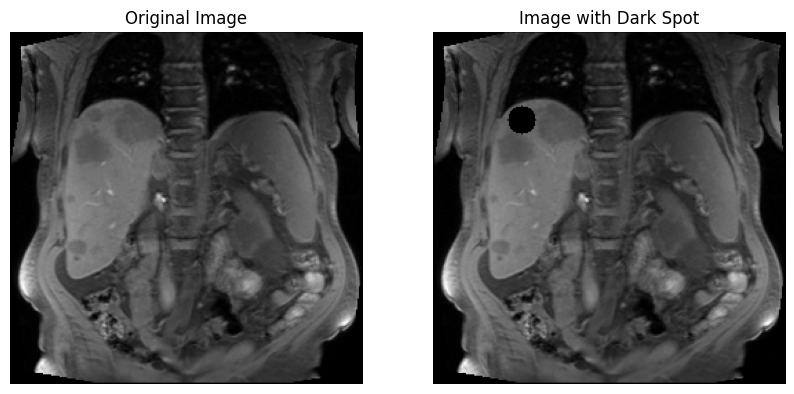

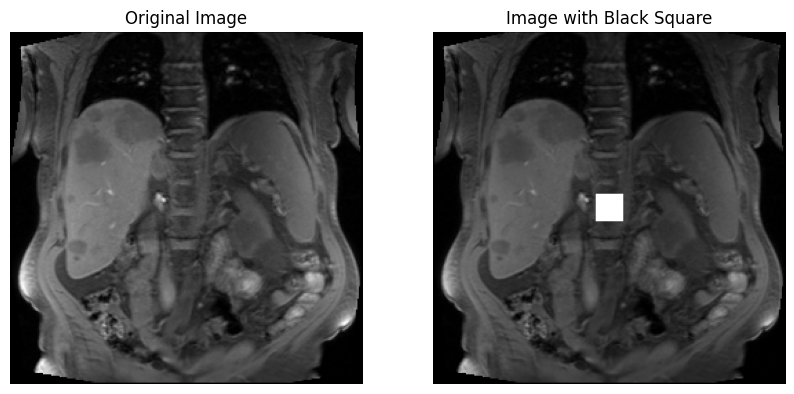

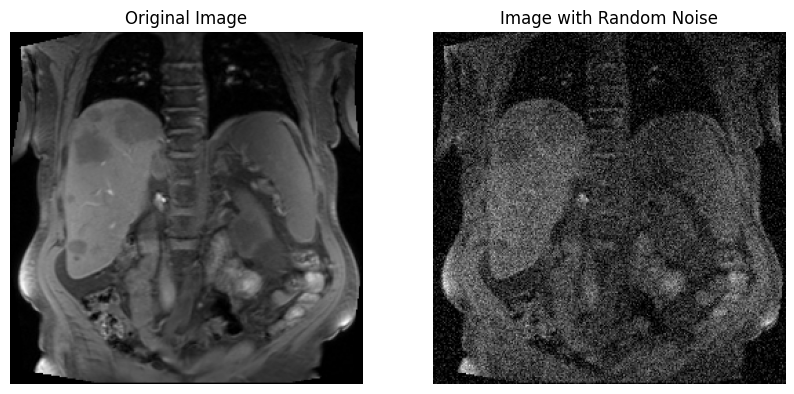

In [3]:
def create_dark_spot(image, center, radius, intensity_reduction):
    """
    Create a dark spot in the image.

    Parameters:
    - image: 2D numpy array representing the image.
    - center: Tuple (x, y) representing the center of the dark spot.
    - radius: Radius of the dark spot.
    - intensity_reduction: Factor by which to reduce the intensity (0 < factor < 1).

    Returns:
    - Modified image with the dark spot.
    """
    x_center, y_center = center
    y_indices, x_indices = np.ogrid[:image.shape[0], :image.shape[1]]
    mask = (x_indices - x_center) ** 2 + (y_indices - y_center) ** 2 <= radius ** 2
    image[mask] *= intensity_reduction
    return image

def create_black_square(image, top_left, size, fill_value=0):
    """
    Create a black square in the image.

    Parameters:
    - image: 2D numpy array representing the image.
    - top_left: Tuple (x, y) representing the top-left corner of the square.
    - size: Size of the square (length of one side).

    Returns:
    - Modified image with the black square.
    """
    x_start, y_start = top_left
    x_end = min(x_start + size, image.shape[1])
    y_end = min(y_start + size, image.shape[0])
    image[y_start:y_end, x_start:x_end] = fill_value
    return image

def add_random_noise(image, noise_level=0.1):
    """
    Add random Gaussian noise to the image.

    Parameters:
    - image: 2D numpy array representing the image.
    - noise_level: Standard deviation of the Gaussian noise.

    Returns:
    - Noisy image.
    """
    noise = np.random.normal(0, noise_level, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 1)  # Ensure pixel values are within valid range
    return noisy_image



tmp_img = data_t1[1, :, :].copy()
modified_img_circle = create_dark_spot(tmp_img.copy(), center=(tmp_img.shape[1]//4, tmp_img.shape[0]//4), radius=10, intensity_reduction=0.0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(tmp_img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(modified_img_circle, cmap='gray')
ax[1].set_title('Image with Dark Spot')
ax[1].axis('off')
plt.show()

modified_img_square = create_black_square(tmp_img.copy(), top_left=(tmp_img.shape[1]//2 - 10, tmp_img.shape[0]//2 - 10), size=20, fill_value=1)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(tmp_img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(modified_img_square, cmap='gray')
ax[1].set_title('Image with Black Square')
ax[1].axis('off')
plt.show()

noisy_img = add_random_noise(tmp_img.copy(), noise_level=0.1)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(tmp_img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title('Image with Random Noise')
ax[1].axis('off')
plt.show()


#

In [4]:
# create new data and store changed in csv
# indices 1,5,7,10

data_csv = pd.DataFrame(columns=['index', 'description'])
images_t1 = []
images_bold = []
images_diffusion = []
images_dixon = []
descriptions = []
indices = []
for index in [1,5,7,10]:
    img_t1 = data_t1[index, :, :].copy()
    img_bold = data_bold[index, :, :].copy()
    img_diffusion = data_diffusion[index, :, :].copy()
    img_dixon = data_dixon[index, :, :].copy()

    location_circle = (img_t1.shape[1]//2, img_t1.shape[0]//2)
    location_square = (img_t1.shape[1]//2 - 10, img_t1.shape[0]//2 - 10)
    size_square = 20
    noise_level = 0.1
    radius = 10

    #img_t1_circle = create_dark_spot(img_t1.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #img_bold_circle = create_dark_spot(img_bold.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #img_diffusion_circle = create_dark_spot(img_diffusion.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #images_t1.append(img_t1_circle)
    #images_bold.append(img_bold_circle)
    #images_diffusion.append(img_diffusion_circle)
    #images_dixon.append(img_dixon)
    #descriptions.append(f"Image {index} with dark spot at {location_circle} and radius {radius}")
    #indices.append(index)
#
    #location_circle = (img_t1.shape[1]//4, img_t1.shape[0]//4)
    #img_t1_circle = create_dark_spot(img_t1.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #img_bold_circle = create_dark_spot(img_bold.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #img_diffusion_circle = create_dark_spot(img_diffusion.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #images_t1.append(img_t1_circle)
    #images_bold.append(img_bold_circle)
    #images_diffusion.append(img_diffusion_circle)
    #images_dixon.append(img_dixon)
    #descriptions.append(f"Image {index} with dark spot at {location_circle} and radius {radius}")
    #indices.append(index)

    #location_circle = (img_t1.shape[1]//2, img_t1.shape[0]//4)
    #img_t1_circle = create_dark_spot(img_t1.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #img_bold_circle = create_dark_spot(img_bold.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #img_diffusion_circle = create_dark_spot(img_diffusion.copy(), center=location_circle, radius=radius, intensity_reduction=0.0)
    #images_t1.append(img_t1_circle)
    #images_bold.append(img_bold_circle)
    #images_diffusion.append(img_diffusion_circle)
    #images_dixon.append(img_dixon)
    #descriptions.append(f"Image {index} with dark spot at {location_circle} and radius {radius}")
    #indices.append(index)

    #location_square = (img_t1.shape[1]//2 - 10, img_t1.shape[0]//2 - 10)
    #img_t1_square = create_black_square(img_t1.copy(), top_left=location_square, size=size_square, fill_value=0)
    #img_bold_square = create_black_square(img_bold.copy(), top_left=location_square, size=size_square, fill_value=0)
    #img_diffusion_square = create_black_square(img_diffusion.copy(), top_left=location_square, size=size_square, fill_value=0)
    #images_t1.append(img_t1_square)
    #images_bold.append(img_bold_square)
    #images_diffusion.append(img_diffusion_square)
    #images_dixon.append(img_dixon)
    #descriptions.append(f"Image {index} with black square at {location_square} and size {size_square}")
    #indices.append(index)

    # sample random location for square
    for _ in range(5):
        location_square = (np.random.randint(0, img_t1.shape[1]-size_square-40), np.random.randint(0, img_t1.shape[0]-size_square-40))
        #location_square = (img_t1.shape[1]//2 - 10, img_t1.shape[0]//2 - 10)
        img_t1_square = create_black_square(img_t1.copy(), top_left=location_square, size=size_square, fill_value=1)
        img_bold_square = create_black_square(img_bold.copy(), top_left=location_square, size=size_square, fill_value=1)
        img_diffusion_square = create_black_square(img_diffusion.copy(), top_left=location_square, size=size_square, fill_value=1)
        images_t1.append(img_t1_square)
        images_bold.append(img_bold_square)
        images_diffusion.append(img_diffusion_square)
        images_dixon.append(img_dixon)
        descriptions.append(f"Image {index} with bright square at {location_square} and size {size_square}")
        indices.append(index)

    img_t1_noise = add_random_noise(img_t1.copy(), noise_level=noise_level)
    img_bold_noise = add_random_noise(img_bold.copy(), noise_level=noise_level)
    img_diffusion_noise = add_random_noise(img_diffusion.copy(), noise_level=noise_level)
    img_t1_noise = add_random_noise(img_t1.copy(), noise_level=noise_level)
    images_t1.append(img_t1_noise)
    images_bold.append(img_bold_noise)
    images_diffusion.append(img_diffusion_noise)
    images_dixon.append(img_dixon)
    descriptions.append(f"Image {index} with random noise, noise level {noise_level}")
    indices.append(index)

    #noise_level = 0.02
    #img_t1_noise = add_random_noise(img_t1.copy(), noise_level=noise_level)
    #img_bold_noise = add_random_noise(img_bold.copy(), noise_level=noise_level)
    #img_diffusion_noise = add_random_noise(img_diffusion.copy(), noise_level=noise_level)
    #img_t1_noise = add_random_noise(img_t1.copy(), noise_level=noise_level)
    #images_t1.append(img_t1_noise)
    #images_bold.append(img_bold_noise)
    #images_diffusion.append(img_diffusion_noise)
    #images_dixon.append(img_dixon)
    #descriptions.append(f"Image {index} with random noise, noise level {noise_level}")
    #indices.append(index)
#
    #noise_level = 0.5
    #img_t1_noise = add_random_noise(img_t1.copy(), noise_level=noise_level)
    #img_bold_noise = add_random_noise(img_bold.copy(), noise_level=noise_level)
    #img_diffusion_noise = add_random_noise(img_diffusion.copy(), noise_level=noise_level)
    #img_t1_noise = add_random_noise(img_t1.copy(), noise_level=noise_level)
    #images_t1.append(img_t1_noise)
    #images_bold.append(img_bold_noise)
    #images_diffusion.append(img_diffusion_noise)
    #images_dixon.append(img_dixon)
    #descriptions.append(f"Image {index} with random noise, noise level {noise_level}")
    #indices.append(index)

img_t1 = np.stack(images_t1, axis=0)
img_bold = np.stack(images_bold, axis=0)
img_diffusion = np.stack(images_diffusion, axis=0)
img_dixon = np.stack(images_dixon, axis=0)

data_csv['index'] = indices
data_csv['description'] = descriptions

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

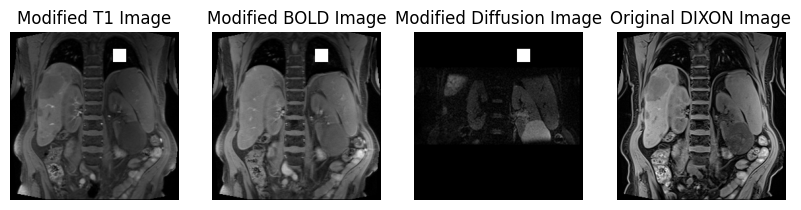

In [5]:
index = 15
fig, ax = plt.subplots(1, 4, figsize=(10, 5))
ax[0].imshow(img_t1[index, :, :], cmap='gray')
ax[0].set_title('Modified T1 Image')
ax[0].axis('off')
ax[1].imshow(img_bold[index, :, :], cmap='gray')
ax[1].set_title('Modified BOLD Image')
ax[1].axis('off')
ax[2].imshow(img_diffusion[index, :, :], cmap='gray')
ax[2].set_title('Modified Diffusion Image')
ax[2].axis('off')
ax[3].imshow(img_dixon[index, :, :], cmap='gray')
ax[3].set_title('Original DIXON Image')
ax[3].axis('off')

In [7]:
save_path = "../data/my_data_uncertainity/test"
data_csv.to_csv(save_path + "/modification_descriptions.csv", index=False)

print(img_t1.shape)
np.save(save_path + "/T1_mapping_fl2d.npy", img_t1)
np.save(save_path + "/BOLD.npy", img_bold)
np.save(save_path + "/Diffusion.npy", img_diffusion)
np.save(save_path + "/DIXON.npy", img_dixon)

(24, 256, 256)


## Analysis

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

dataset = CreateDatasetSynthesis_with_masks(phase="test", input_path="../data/my_data2")
#data_loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False, num_workers=1, pin_memory=False, drop_last=True)

epistemic_uncertainity = np.load("../results/my_hyperdm_experiment_pret_3/epistemic_uncertainty.npy")
aleatoric_uncertainity = np.load("../results/my_hyperdm_experiment_pret_3/aleatoric_uncertainty.npy")
epistemic_uncertainity = np.array([epistemic_uncertainity[i, 0, 0, :, :] for i in range(epistemic_uncertainity.shape[0])])
aleatoric_uncertainity = np.array([aleatoric_uncertainity[i, 0, 0, :, :] for i in range(aleatoric_uncertainity.shape[0])])

mean_aleatoric = np.mean(aleatoric_uncertainity, axis=0)
mean_epistemic = np.mean(epistemic_uncertainity, axis=0)

def normalize_per_image(image, factor):
    # normalize one image such that it sums up to 1
    image = (image - np.min(image)) / factor
    return image/np.sum(image)

sum_aleatoric = np.mean(np.sum(aleatoric_uncertainity, axis=(1,2)))
sum_epistemic = np.mean(np.sum(epistemic_uncertainity, axis=(1,2)))


aleatoric_uncertainity_normalized = np.stack([normalize_per_image(aleatoric_uncertainity[i,:,:].copy(), factor=sum_aleatoric) for i in range(aleatoric_uncertainity.shape[0])])
epistemic_uncertainity_normalized = np.stack([normalize_per_image(epistemic_uncertainity[i,:,:].copy(), factor=sum_epistemic) for i in range(epistemic_uncertainity.shape[0])])

mean_aleatoric_normalized = np.mean(aleatoric_uncertainity_normalized, axis=0)
mean_epistemic_normalized = np.mean(epistemic_uncertainity_normalized, axis=0)

padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0


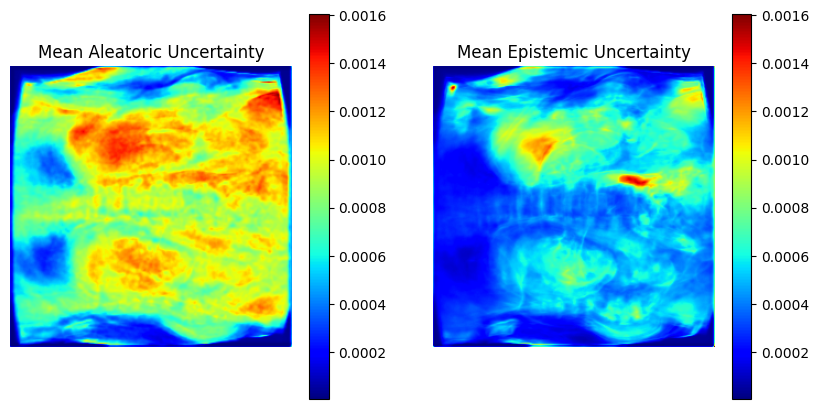

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
im_au = ax[0].imshow(mean_aleatoric, cmap='jet')
ax[0].set_title('Mean Aleatoric Uncertainty')
ax[0].figure.colorbar(im_au, ax=ax[0])
ax[0].axis('off')
ax[1].imshow(mean_epistemic, cmap='jet')
ax[1].set_title('Mean Epistemic Uncertainty')
ax[1].figure.colorbar(im_au, ax=ax[1])
ax[1].axis('off')
plt.show()

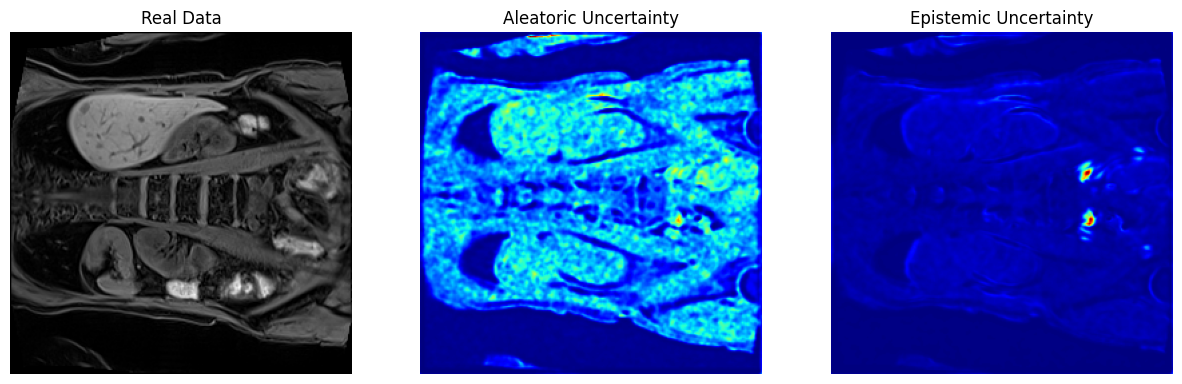

In [14]:
# get 10th element from dataset
# indices 1,5,7,10, 50
index = 51
x1, x2, x3, real_data, m1, m2, m3, m_target = dataset[index]

aleatoric_tmp = aleatoric_uncertainity[index, :, :]
epistemic_tmp = epistemic_uncertainity[index, :, :]

fig, ax = plt.subplots(1, 3, figsize=(15, 10))
ax[0].imshow(real_data[0, :, :].cpu(), cmap='gray')
ax[0].set_title('Real Data')
ax[0].axis('off')
im_au = ax[1].imshow(aleatoric_tmp, cmap='jet')
ax[1].set_title('Aleatoric Uncertainty')
#ax[1].figure.colorbar(im_au, ax=ax[1])
ax[1].axis('off')
im_ep = ax[2].imshow(epistemic_tmp, cmap='jet')
ax[2].set_title('Epistemic Uncertainty')
#ax[2].figure.colorbar(im_ep, ax=ax[2])
ax[2].axis('off')
plt.show()


## Check manipulated data

In [3]:
csv_data = pd.read_csv("../data/my_data_uncertainity/test/modification_descriptions.csv")

dataset_manipulated = CreateDatasetSynthesis(phase="test", input_path="../data/my_data_uncertainity")

aleatoric_uncertainity = np.load("../data/my_data_uncertainity/test/my_hyperdm_experiment_pret_3/aleatoric_uncertainty.npy")[:,0,0,:,:]
epistemic_uncertainity = np.load("../data/my_data_uncertainity/test/my_hyperdm_experiment_pret_3/epistemic_uncertainty.npy")[:,0,0,:,:]

padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0


In [6]:
csv_data.head(10)

,index,description
0,1,"Image 1 with bright square at (143, 96) and si..."
1,1,"Image 1 with bright square at (88, 142) and si..."
2,1,"Image 1 with bright square at (59, 124) and si..."
3,1,"Image 1 with bright square at (195, 141) and s..."
4,1,"Image 1 with bright square at (0, 87) and size 20"
5,1,"Image 1 with random noise, noise level 0.1"
6,5,"Image 5 with bright square at (132, 120) and s..."
7,5,"Image 5 with bright square at (32, 86) and siz..."
8,5,"Image 5 with bright square at (0, 21) and size 20"
9,5,"Image 5 with bright square at (153, 64) and si..."


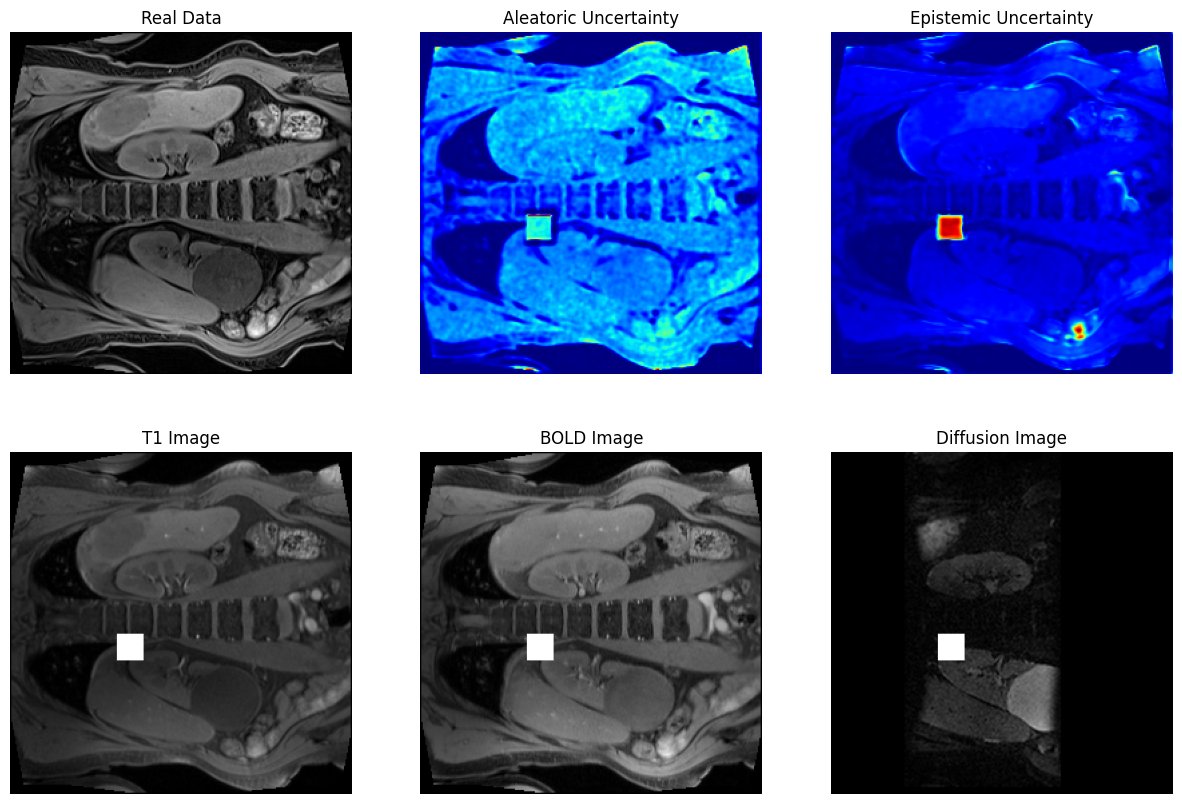

In [12]:
index = 20
x_bold, x_diffusion, x_t1, x_dixon = dataset_manipulated[index]

aleatoric_tmp = aleatoric_uncertainity[index, :, :]
epistemic_tmp = epistemic_uncertainity[index, :, :]

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(x_dixon[0,:,:], cmap='gray')
ax[0, 0].set_title('Real Data')
ax[0, 0].axis('off')
im_au = ax[0, 1].imshow(aleatoric_tmp, cmap='jet')
ax[0, 1].set_title('Aleatoric Uncertainty')
#ax[1, 0].figure.colorbar(im_au, ax=ax[1, 0])
ax[0, 1].axis('off')
im_ep = ax[0, 2].imshow(epistemic_tmp, cmap='jet')
ax[0, 2].set_title('Epistemic Uncertainty')
#ax[1, 1].figure.colorbar(im_ep, ax=ax[1, 1])
ax[0, 2].axis('off')
ax[1, 0].imshow(x_t1[0,:,:], cmap='gray')
ax[1, 0].set_title('T1 Image')
ax[1, 0].axis('off')
ax[1, 1].imshow(x_bold[0,:,:], cmap='gray')
ax[1, 1].set_title('BOLD Image')
ax[1, 1].axis('off')
ax[1, 2].imshow(x_diffusion[0,:,:], cmap='gray')
ax[1, 2].set_title('Diffusion Image')
ax[1, 2].axis('off')
plt.show()

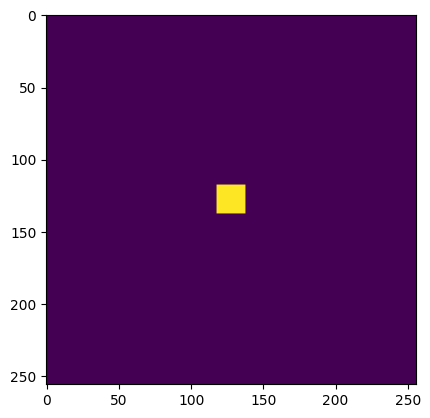

In [15]:
plt.imshow(x_bold[0])

## Debug HyperDM Test

In [4]:
from backbones.ncsnpp_generator_adagn_feat import NCSNpp
from hyperdm.hyperdm import HyperDM_MU_Diff_Single
from train_utils import (
    Posterior_Coefficients,
    Diffusion_Coefficients,
)
from dataset.dataset_dixon import CreateDatasetSynthesis
from argparse import Namespace
import os
import torch
device = "cpu"

W1014 15:01:40.801000 3721435 torch/utils/cpp_extension.py:118] No CUDA runtime is found, using CUDA_HOME='/home/students/studweilc1/.conda/envs/cornelius_new'


W1014 15:01:41.108000 3721435 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W1014 15:01:41.108000 3721435 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
W1014 15:01:41.237000 3721435 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W1014 15:01:41.237000 3721435 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


module_path = /home/students/studweilc1/MU-Diff/utils/op


In [16]:
# create args object with Namespace object

args = Namespace(
    exp="my_hyperdm_experiment_pret_3",
    input_path="../data/my_data_uncertainity",
    results_path="results/",
    num_test_images=None,
    M=4,
    N=4,
    hyper_net_dims=[32, 64, 128],
    ch_mult = [1,1,2],
    num_res_blocks=1,
    nz = 100,
    checkpoint="content.pth",
    not_use_tanh=False,
    z_emb_dim=256,
    t_emb_dim=256,
    ngf=64,
    num_channels_dae=32,
    attn_resolutions=[16],
    dropout=0.0,
    resamp_with_conv=True,
    image_size=256,
    num_timesteps=4,
    conditional=True,
    fir=True,
    fir_kernel=[1, 3, 3, 1],
    skip_rescale=True,
    resblock_type="biggan",
    progressive="output_skip",
    progressive_input="residual",
    embedding_type="fourier",
    fourier_scale=16,
    noise_schedule="linear",
    progressive_combine="sum",
    num_channels=1,
    n_mlp=3,
    beta_min=0.1,
    beta_max=20.0,
    use_geometric=False,
    centered=True
)

In [17]:
primary_net = NCSNpp(args).to(device)
pos_coeff = Posterior_Coefficients(args, device)

hyperdm_model = HyperDM_MU_Diff_Single(
    primary_net=primary_net,
    hyper_net_dims=args.hyper_net_dims,
    diffusion_args=args,
    pos_coeff=pos_coeff
).to(device)

checkpoint_path = os.path.join(args.results_path, args.exp, args.checkpoint)
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    state_dict = checkpoint['hyperdm_model_dict']
    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] # remove `module.`
        new_state_dict[name] = v
    hyperdm_model.load_state_dict(new_state_dict)
    print(f"Loaded checkpoint from {checkpoint_path}")
else:
    print(f"WARNING: Checkpoint not found at {checkpoint_path}. Using randomly initialized weights.")

hyperdm_model.eval()


HyperDM_MU_Diff_Single(
  (primary_net): NCSNpp(
    (act): SiLU()
    (pyramid_upsample): Upsample()
    (all_modules): ModuleList(
      (0): GaussianFourierProjection()
      (1): Linear(in_features=64, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3-6): 4 x ConvFeatBlock(
        (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (group_norm): GroupNorm_Conv(
          (norm): GroupNorm(8, 32, eps=1e-06, affine=False)
        )
        (act): SiLU()
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (7): ResnetBlockBigGANpp_Adagn(
        (GroupNorm_0): AdaptiveGroupNorm(
          (norm): GroupNorm(32, 128, eps=1e-06, affine=False)
          (style): Linear(in_features=256, out_features=256, bias=True)
        )
        (Conv_0): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (Dense_0): Linear(in_features=128, out_features=3

In [7]:

# --- Load Data ---
dataset = CreateDatasetSynthesis(phase="test", input_path=args.input_path)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)

all_real_data, all_mean_predictions, all_aleatoric, all_epistemic = [], [], [], []


padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0


In [8]:
x1, x2, x3, real_data = next(iter(data_loader))


/tmp/test_env/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [9]:

cond1, cond2, cond3, real_data = [d.to(device) for d in (x1, x2, x3, real_data)]
x_init = torch.randn_like(real_data)

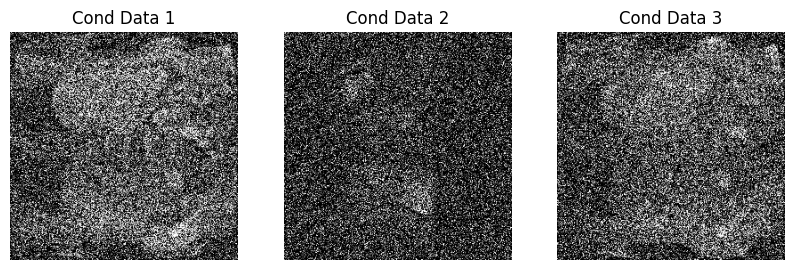

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(cond1[0,0,:,:].cpu(), cmap='gray')
ax[0].set_title('Cond Data 1')
ax[0].axis('off')
ax[1].imshow(cond2[0,0,:,:].cpu(), cmap='gray')
ax[1].set_title('Cond Data 2')
ax[1].axis('off')
ax[2].imshow(cond3[0,0,:,:].cpu(), cmap='gray')
ax[2].set_title('Cond Data 3')
ax[2].axis('off')
plt.show()

#### Debug Hyperdm

In [ ]:

# --- Loop over test images ---
if args.num_test_images is None:
    args.num_test_images = len(data_loader)
else:
    args.num_test_images = min(args.num_test_images, len(data_loader))
for i, (x1, x2, x3, real_data) in enumerate(tqdm(data_loader, desc="Processing Test Images")):
    if i >= args.num_test_images:
        break
    if i % 10 == 0:
        print(f"Processing image {i+1}/{args.num_test_images}")

    cond_data1, cond_data2, cond_data3, real_data = [d.to(device) for d in (x1, x2, x3, real_data)]
    x_init = torch.randn_like(real_data)

    epistemic_uncertainty, aleatoric_uncertainty, mean_prediction = hyperdm_model.get_mean_variance(
        M=args.M, N=args.N, cond1=cond_data1, cond2=cond_data2, cond3=cond_data3,
        x_init=x_init, device=device, progress=False
    )

    all_real_data.append(real_data.cpu())
    all_mean_predictions.append(mean_prediction.cpu())
    all_aleatoric.append(aleatoric_uncertainty.cpu())
    all_epistemic.append(epistemic_uncertainty.cpu())